In [ ]:
# Meraj Nushin
# Date: 5/7/2026

# Healthcare Data Analysis
# This notebook analyzes healthcare data to answer key questions about patient characteristics, 
# conditions leading to hospital visits, factors increasing claim costs, 
# and trends in healthcare utilization over time. 
# The analysis aims to provide insights that can help improve patient care and 
# manage healthcare resources effectively.

# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

            Name  Age  Gender Blood Type Medical Condition Date of Admission  \
0  Bobby Jackson   30    Male         B-            Cancer        2024-01-31   
1   Leslie Terry   62    Male         A+           Obesity        2019-08-20   
2    Danny Smith   76  Female         A-           Obesity        2022-09-22   
3   Andrew Watts   28  Female         O+          Diabetes        2020-11-18   
4  Adrienne Bell   43  Female        AB+            Cancer        2022-09-19   

             Doctor                    Hospital Insurance Provider  \
0     Matthew Smith             Sons and Miller         Blue Cross   
1   Samantha Davies                     Kim Inc           Medicare   
2  Tiffany Mitchell                    Cook PLC              Aetna   
3       Kevin Wells  Hernandez Rogers and Vang,           Medicare   
4    Kathleen Hanna                 White-White              Aetna   

   Billing Amount  Room Number Admission Type Discharge Date   Medication  \
0     18856.28131    

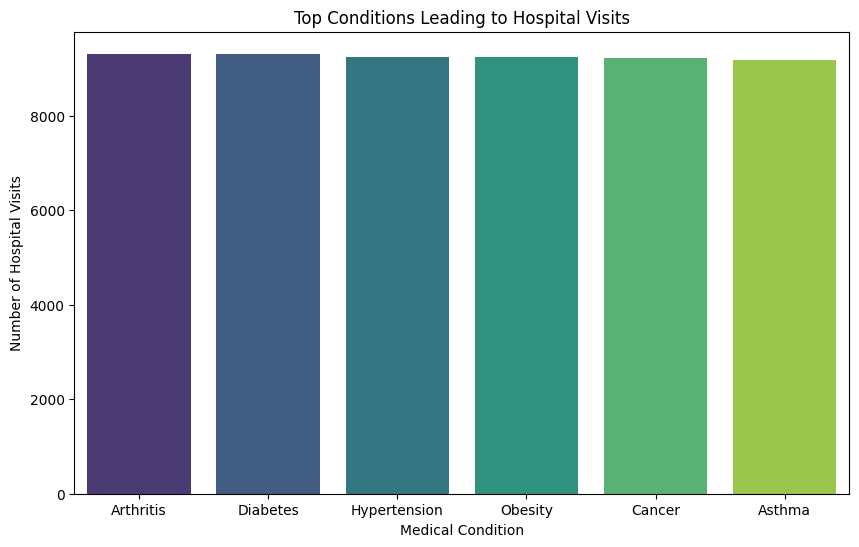

In [ ]:
# || Which conditions lead to the most hospital visits? ||

# Load the dataset
data = pd.read_csv('../excel/healthcare_dataset.csv')

# Display the first few rows of the dataset
print(data.head())

# Check for missing values
print(data.isnull().sum())

# Analyze the conditions leading to hospital visits
# Group the data by 'Condition' and count the number of hospital visits
condition_visits = data.groupby('Medical Condition').size().reset_index(name='Hospital_Visits')

# Sort the conditions by the number of hospital visits
condition_visits = condition_visits.sort_values(by='Hospital_Visits', ascending=False)

# Display the top conditions leading to hospital visits
print(condition_visits.head())

# Visualize the top conditions leading to hospital visits
plt.figure(figsize=(10, 6))
sns.barplot(x='Medical Condition', y='Hospital_Visits', data=condition_visits.head(10), palette='viridis')
plt.title('Top Conditions Leading to Hospital Visits')
plt.xlabel('Medical Condition')
plt.ylabel('Number of Hospital Visits')
plt.show()

                   Name  Hospital_Visits
27709  Michael Williams               24
27646     Michael Smith               23
32614      Robert Smith               22
15497       James Brown               19
15794       James Smith               18


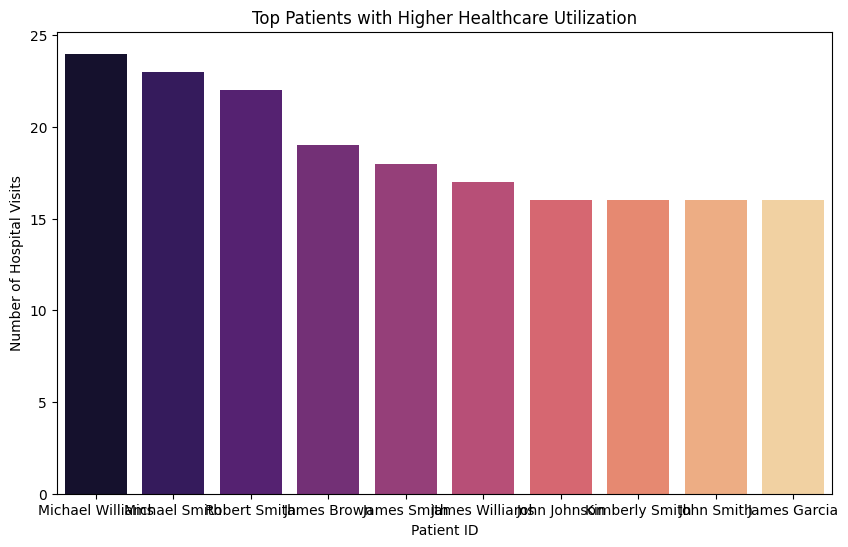

In [ ]:
# || Which patients have higher utilization of healthcare services? || 

# Group the data by 'Patient ID' and count the number of hospital visits
patient_visits = data.groupby('Name').size().reset_index(name='Hospital_Visits')

# Sort the patients by the number of hospital visits
patient_visits = patient_visits.sort_values(by='Hospital_Visits', ascending=False)

# Display the top patients with higher healthcare utilization
print(patient_visits.head())

# Visualize the top patients with higher healthcare utilization
plt.figure(figsize=(10, 6))
sns.barplot(x='Name', y='Hospital_Visits', data=patient_visits.head(10), palette='magma')
plt.title('Top Patients with Higher Healthcare Utilization')
plt.xlabel('Patient ID')
plt.ylabel('Number of Hospital Visits')
plt.show()

  Has_Chronic_Condition  Hospital_Visits
0                    No            55500


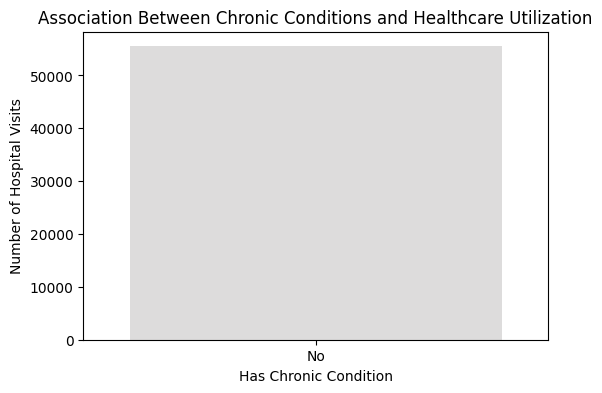

In [ ]:
# || Analyze the association between chronic conditions and healthcare utilization ||

# Create a new column to indicate whether a patient has a chronic condition
data['Has_Chronic_Condition'] = data['Medical Condition'].apply(lambda x: 'Yes' if 'Chronic' in x else 'No')

# Group the data by 'Has_Chronic_Condition' and count the number of hospital visits
chronic_visits = data.groupby('Has_Chronic_Condition').size().reset_index(name='Hospital_Visits')

# Display the association between chronic conditions and healthcare utilization
print(chronic_visits)

# Visualize the association between chronic conditions and healthcare utilization
plt.figure(figsize=(6, 4))
sns.barplot(x='Has_Chronic_Condition', y='Hospital_Visits', data=chronic_visits, palette='coolwarm')
plt.title('Association Between Chronic Conditions and Healthcare Utilization')
plt.xlabel('Has Chronic Condition')
plt.ylabel('Number of Hospital Visits')
plt.show()

  Medical Condition  Average_Claim_Cost
5           Obesity        25805.971259
3          Diabetes        25638.405577
1            Asthma        25635.249359
0         Arthritis        25497.327056
4      Hypertension        25497.095761


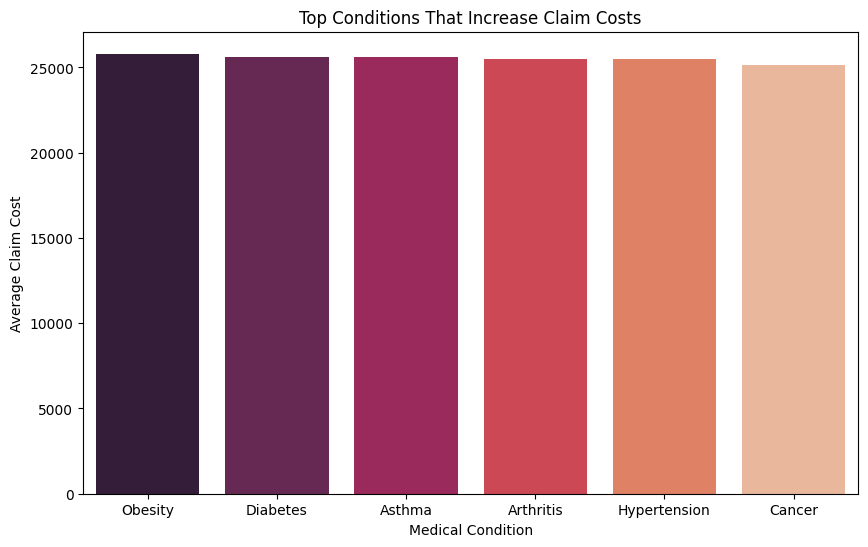

In [ ]:
# || What factors increase claim costs? ||

# Group the data by 'Medical Condition' and calculate the average claim cost
condition_costs = data.groupby('Medical Condition')['Billing Amount'].mean().reset_index(name='Average_Claim_Cost')

# Sort the conditions by average claim cost
condition_costs = condition_costs.sort_values(by='Average_Claim_Cost', ascending=False)

# Display the top conditions that increase claim costs
print(condition_costs.head())

# Visualize the factors that increase claim costs   
plt.figure(figsize=(10, 6))
sns.barplot(x='Medical Condition', y='Average_Claim_Cost', data=condition_costs.head(10), palette='rocket')
plt.title('Top Conditions That Increase Claim Costs')
plt.xlabel('Medical Condition')
plt.ylabel('Average Claim Cost')
plt.show()

   Date of Admission  Hospital_Visits
0         2019-05-01              686
1         2019-06-01              907
2         2019-07-01              957
3         2019-08-01             1001
4         2019-09-01              936
..               ...              ...
56        2024-01-01              909
57        2024-02-01              880
58        2024-03-01              906
59        2024-04-01              946
60        2024-05-01              213

[61 rows x 2 columns]


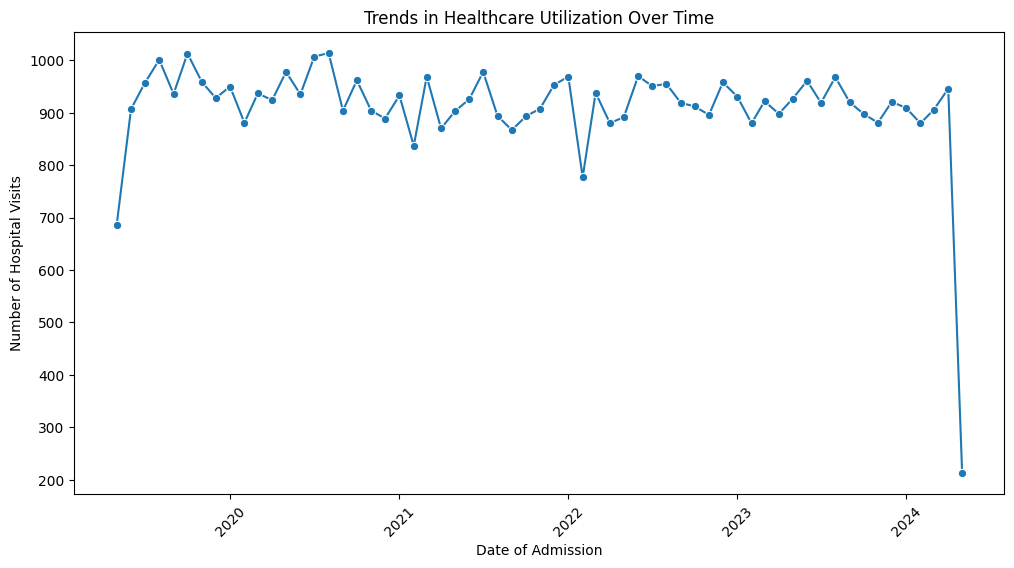

In [ ]:
# || What trends appear over time? ||

# Convert the 'Date of Admission' column to datetime format
data['Date of Admission'] = pd.to_datetime(data['Date of Admission'])

# Group the data by admission month and count the number of hospital visits
time_trends = (
	data.groupby(data['Date of Admission'].dt.to_period('M'))
		.size()
		.reset_index(name='Hospital_Visits')
)
time_trends['Date of Admission'] = time_trends['Date of Admission'].dt.to_timestamp()

# Display the trends in healthcare utilization over time
print(time_trends)

# Visualize the trends in healthcare utilization over time
plt.figure(figsize=(12, 6))
sns.lineplot(x='Date of Admission', y='Hospital_Visits', data=time_trends, marker='o')
plt.title('Trends in Healthcare Utilization Over Time')
plt.xlabel('Date of Admission')
plt.ylabel('Number of Hospital Visits')
plt.xticks(rotation=45)
plt.show()